# Práctica 03. Análisis Estadistico de señales

**Estudiante:** Juliana Sarmiento Arciniegas

**Identificación:** 1037667898

 Funciones en Python:

*   **mean:** Calcula el promedio de un conjunto de datos (np.mean())
*   **var:** Calcula la varianza de un conjunto de datos, es decir mide cuánto se dispersan los datos respecto a la media.
*   **std:** Calcula la desviación estandar (raiz cuadrada de la varianza) y arroja valores más faciles de interpretar que la varianza

In [1]:
import numpy as np
import scipy.io as sio
import matplotlib.pyplot as plt
from scipy.signal import find_peaks #ayudará más adelnate a buscar picos de señales
import pandas as pd
from scipy.stats import shapiro #Prueba de Shapiro
from scipy.stats import levene #Prueba de homocedasticidad
from scipy.stats import mannwhitneyu #Prueba de Mann Whitney U
from statsmodels.tsa.stattools import adfuller #Prueba de Augmented Dickey-Fuller

## Exportar los datos de interes para ECG

In [2]:
# Cargar archivo .mat
mat = sio.loadmat("signals.mat")

# Ver qué variables contiene para saber cuales exportar
print(mat.keys())

#verificar el tamaño del arreglo
raw = mat['ECG_asRecording']
print(raw.shape)

dict_keys(['__header__', '__version__', '__globals__', 'Fs', 'ECG_asRecording', 'ECG_filtered', 'EMG_filtered1', 'EMG_filtered2', 'EMG_asRecording1', 'EMG_asRecording2'])
(1, 30720)


Se hará uso de la funcion np.squeeze ya que esta permite pasar de un vector 2D, como se observa en el tamaño del vector ECG_asRecording, a un arreglo plano de una dimensión. Esto es importante para realizar operaciones matemáticas a lo largo del informe.

In [3]:
fs = float(np.squeeze(mat['Fs']))                    # frecuencia de muestreo
ecg_original = np.squeeze(mat['ECG_asRecording'])    # senal original, tal cual se registro
ecg_filtrada = np.squeeze(mat['ECG_filtered'])       # senal filtrada

print("Frecuencia de muestreo:", fs, "Hz")
print("Tamano ECG cruda:", ecg_original.shape)
print("Tamano ECG filtrada:", ecg_filtrada.shape)

Frecuencia de muestreo: 1024.0 Hz
Tamano ECG cruda: (30720,)
Tamano ECG filtrada: (30720,)


Ya teniendo un tamaño de (30720,) es más fácil continuar con las operaciones a lo largo del taller.

## Creación de la funcion RMS

### Valor cuadrático medio (RMS)

$$x_{RMS} = \left[\frac{1}{N}\sum_{i=1}^{N} x(i)^2\right]^{1/2}$$

In [4]:
def rms(x):
    x = np.asarray(x, dtype=float)   # asarray -> asegura que la entrada sea un arreglo de numpy
    return np.sqrt(np.mean(x**2))

# prueba rapida con una senoidal de amplitud conocida (RMS teorico = A/sqrt(2))
t_prueba = np.linspace(0, 1, 1000, endpoint=False)
seno_prueba = 5*np.sin(2*np.pi*10*t_prueba)
print("RMS teorico:  ", 5/np.sqrt(2))
print("RMS calculado:", rms(seno_prueba))

RMS teorico:   3.5355339059327373
RMS calculado: 3.5355339059327378


## Tiempo de duración de las señales

In [ ]:
muestras_original = len(ecg_original)#muestras del vector original
muestras_filtrada = len(ecg_filtrada)#muestras del vector filtrado

#calcular el tiempo
tiempo_original = muestras_original/fs # tiempo total = N * (1/fs)
tiempo_filtrado = muestras_filtrada/fs
print("Duracion senal original :", tiempo_original, "s")
print("Duracion senal filtrada :", tiempo_filtrado, "s")

# vector de tiempo (comun a ambas senales, mismo numero de muestras)
tiempo = np.arange(muestras_filtrada)/fs #convertir a un arreglo numpy
print("Vector de tiempo (primeras 5 muestras):", tiempo[:5])

Duracion senal original : 30.0 s
Duracion senal filtrada : 30.0 s
Vector de tiempo (primeras 5 muestras): [0.         0.00097656 0.00195312 0.00292969 0.00390625]


## Comparativa entre señal filtrada y sin filtrar

Se realiza un recorte en la señal para visualizar solo el comportamiento de las señales en los dos primeros segundos.

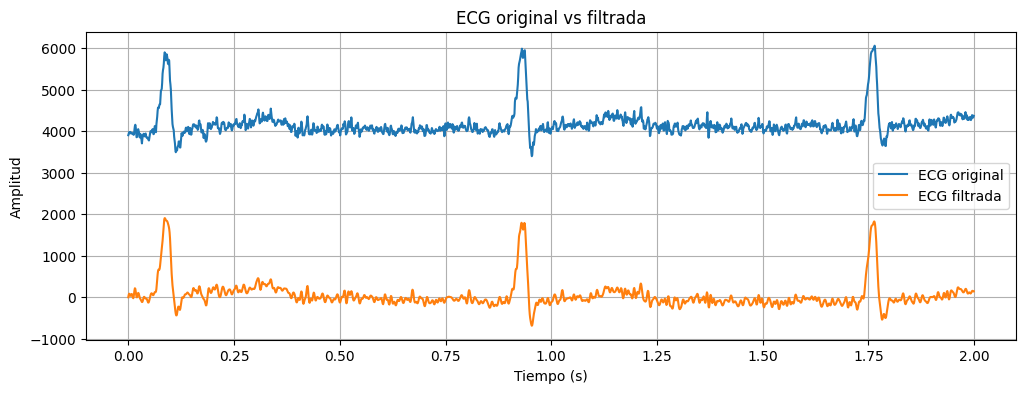

In [8]:
#para ver los datos los primeros 2 segundos
muestras_2s = int(2*fs) #permite ver las muestras de los 2 primeros segundos

#Cortar cada uno de los vectores de interes para visualizar solo las muestras de 2 segundos
tiempo_2 = tiempo[:muestras_2s]
original_ECG2 = ecg_original[:muestras_2s]
filtrada_ECG2 = ecg_filtrada[:muestras_2s]

plt.figure(figsize=(12,4))
plt.plot(tiempo_2, original_ECG2, label="ECG original")
plt.plot(tiempo_2, filtrada_ECG2, label="ECG filtrada")
plt.xlabel("Tiempo (s)")
plt.ylabel("Amplitud")
plt.title("ECG original vs filtrada")
plt.grid()
plt.legend()
plt.show()

La señal original muestra claramente los complejos QRS, con picos pronunciados que corresponden a los latidos cardíacos, con una amplitud que varía alrededor de 4000–6000 unidades, mientras que la señal filtrada se centra alrededor de cero, eliminando el nivel de la línea de referencia presente en la señal original; esto ocurre porque el filtro aplicado atenúa las componentes de muy baja frecuencia responsables del desplazamiento de la línea base, y también el ruido de alta frecuencia (muscular o de red eléctrica), con el objetivo de conservar el rango de frecuencias característico del ECG, típicamente entre 0.5 y 40 Hz [1][2]. La forma de la señal filtrada sigue mostrando todos los picos QRS con la misma amplitud pico a pico que en la señal original alrededor de 1800-2000 unidades, lo que confirma que el filtro no distorsiona la información clínicamente relevante; en el intervalo de 2 segundos se observan 3 picos, lo que sugiere una frecuencia cardíaca cercana a 70-72 latidos por minuto, consistente con el análisis del registro completo de 30 segundos.

## Obtener un ciclo cardiaco de la señal original y la filtrada.

Para obtener los ciclos cardiacos se detectan los picos R con find_peaks, usando una distancia mínima de 0.6 s entre picos (equivalente a un límite superior de aprox. 100 lpm, razonable para un sujeto en reposo). Cada ciclo se define como el segmento de señal **entre dos picos R consecutivos** (por lo que su longitud es variable, ya que el ritmo cardiaco no es perfectamente constante)[3].

Numero de picos R detectados (original): 36


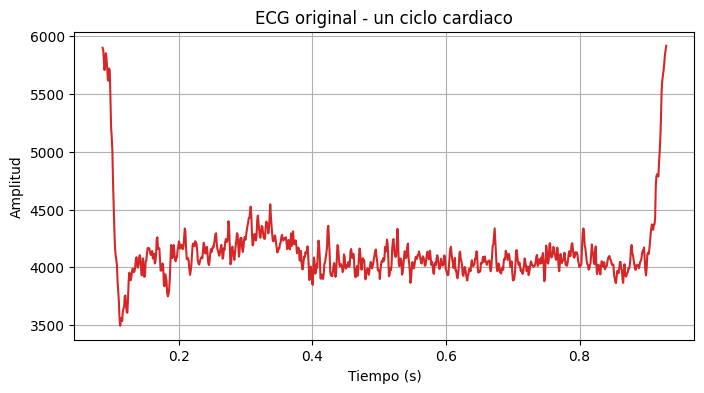

In [9]:
#Senal original
peaks_o, _ = find_peaks(ecg_original, distance=int(0.6*fs))
print("Numero de picos R detectados (original):", len(peaks_o))

ciclo_o = ecg_original[peaks_o[0]:peaks_o[1]]
tiempo_ciclo_o = tiempo[peaks_o[0]:peaks_o[1]]

plt.figure(figsize=(8, 4))
plt.plot(tiempo_ciclo_o, ciclo_o, color='tab:red')
plt.xlabel("Tiempo (s)")
plt.ylabel("Amplitud")
plt.title("ECG original - un ciclo cardiaco")
plt.grid(True)
plt.show()

In [10]:
media_o = np.mean(ciclo_o)
varianza_o = np.var(ciclo_o)
desv_o = np.std(ciclo_o)
rms_o = rms(ciclo_o)

print("El promedio del ciclo cardiaco (original) corresponde a:      ", media_o)
print("La varianza del ciclo cardiaco (original) corresponde a:      ", varianza_o)
print("La desviacion estandar del ciclo cardiaco (original) corresponde a:", desv_o)
print("El valor RMS del ciclo cardiaco (original) corresponde a:     ", rms_o)

El promedio del ciclo cardiaco (original) corresponde a:       4131.136266878161
La varianza del ciclo cardiaco (original) corresponde a:       93646.2220564969
La desviacion estandar del ciclo cardiaco (original) corresponde a: 306.01670225086883
El valor RMS del ciclo cardiaco (original) corresponde a:      4142.454957820607


Numero de picos R detectados (filtrada): 36


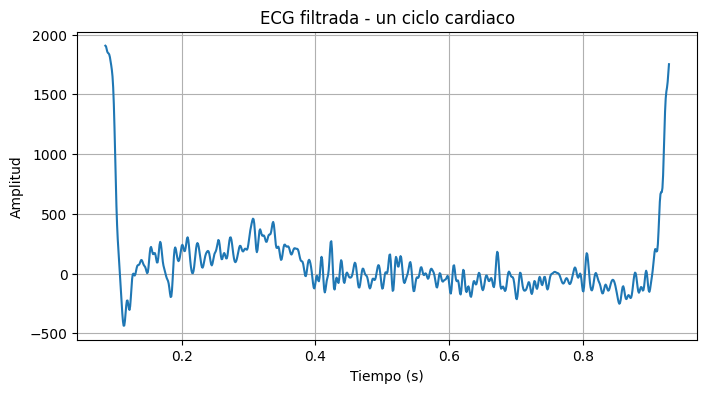

In [11]:
# Senal filtrada
peaks_f, _ = find_peaks(ecg_filtrada, distance=int(0.6*fs))
print("Numero de picos R detectados (filtrada):", len(peaks_f))

ciclo_f = ecg_filtrada[peaks_f[0]:peaks_f[1]]
tiempo_ciclo_f = tiempo[peaks_f[0]:peaks_f[1]]

plt.figure(figsize=(8, 4))
plt.plot(tiempo_ciclo_f, ciclo_f, color='tab:blue')
plt.xlabel("Tiempo (s)")
plt.ylabel("Amplitud")
plt.title("ECG filtrada - un ciclo cardiaco")
plt.grid(True)
plt.show()

In [12]:
media_f = np.mean(ciclo_f)
varianza_f = np.var(ciclo_f)
desv_f = np.std(ciclo_f)
rms_f = rms(ciclo_f)

print("El promedio del ciclo cardiaco (filtrada) corresponde a:      ", media_f)
print("La varianza del ciclo cardiaco (filtrada) corresponde a:      ", varianza_f)
print("La desviacion estandar del ciclo cardiaco (filtrada) corresponde a:", desv_f)
print("El valor RMS del ciclo cardiaco (filtrada) corresponde a:     ", rms_f)

print("\nComparacion original vs. filtrada:")
tabla_comp = pd.DataFrame({
    "Metrica": ["Media", "Varianza", "Desv. estandar", "RMS"],
    "Original": [media_o, varianza_o, desv_o, rms_o],
    "Filtrada": [media_f, varianza_f, desv_f, rms_f]
}).round(2)
print(tabla_comp)

El promedio del ciclo cardiaco (filtrada) corresponde a:       74.00995782055861
La varianza del ciclo cardiaco (filtrada) corresponde a:       96684.31488232457
La desviacion estandar del ciclo cardiaco (filtrada) corresponde a: 310.94101511753735
El valor RMS del ciclo cardiaco (filtrada) corresponde a:      319.62757818893766

Comparacion original vs. filtrada:
          Metrica  Original  Filtrada
0           Media   4131.14     74.01
1        Varianza  93646.22  96684.31
2  Desv. estandar    306.02    310.94
3             RMS   4142.45    319.63


En la señal original, el promedio del ciclo cardíaco se sitúa alrededor de 4131 y cae drásticamente a aproximadamente 74 tras el filtrado. Esta diferencia refleja la eliminación de la componente de muy baja frecuencia y la deriva de la línea base, lo que permite centrar la señal alrededor de cero.

La varianza y la desviación estándar conservan valores muy similares entre la señal original (93 646 y 306) y la filtrada (96 684 y 311). Esto demuestra que la dispersión de los datos respecto a su media, la variabilidad natural del ciclo y la amplitud relativa de los complejos QRS no sufren alteraciones significativas tras el procesamiento.

El error medio cuadrático presenta una reducción drástica de 4142 a 320. Esta caída se explica porque, al remover el offset y centrar la señal en el eje de referencia, la magnitud media de los datos disminuye considerablemente.

En conjunto, esta verificación estadística confirma que el filtrado remueve la continua sin degradar la composición morfológica de la señal de ECG —como los complejos QRS y los valores pico a pico—, garantizando su validez para el diagnóstico médico.

## Referencias

[1] J. Higueras Nafría, "¿Sabes para qué sirven los filtros y cuáles son los valores recomendados?", 
    CardioTeca, 2023. Disponible: https://www.cardioteca.com/pildoras-ecg/5017-sabes-para-que-sirven-los-filtros-y-cuales-son-los-valores-recomendados.html

[2] "Análisis de esquemas de filtrado analógico para señales electrocardiográficas (ECG)", 
    Scientia et Technica, Universidad Tecnológica de Pereira, Año XIII, No. 37, dic. 2007. 
    Disponible: https://www.academia.edu/27980001/An%C3%A1lisis_de_esquemas_de_filtrado_an%C3%A1logo_para_se%C3%B1ales_ECG

[3] J. Pan y W. J. Tompkins, "A Real-Time QRS Detection Algorithm," 
    IEEE Transactions on Biomedical Engineering, vol. BME-32, no. 3, pp. 230-236, 1985.
    Disponible: https://www.robots.ox.ac.uk/~gari/teaching/cdt/A3/readings/ECG/Pan+Tompkins.pdf


    